# IPL Cricket Performance & Strategy Analytics

**Central question:** what performance patterns and match conditions are associated with winning in the IPL?

This notebook is the exploratory companion to `python/ipl_analysis.py` (the production script). It walks
through the same pipeline — load, inspect, clean, engineer features, explore — but with the reasoning
and intermediate checks left visible, the way an actual analysis session looks.

**Data:** IPL Complete Dataset (2008–2024) — `matches.csv` + `deliveries.csv`, originally from
[Cricsheet](https://cricsheet.org), packaged on Kaggle by patrickb1912. See `data/README.md` for the
download link and full column dictionary before running this notebook.

Every number below is computed from whatever is in `../data/`. Nothing here is hard-coded.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

DATA_DIR = "../data"


## 1. Load the data

In [19]:
matches = pd.read_csv(f"{DATA_DIR}/matches.csv")
deliveries = pd.read_csv(f"{DATA_DIR}/deliveries.csv")

print("matches:", matches.shape)
print("deliveries:", deliveries.shape)
matches.head()


matches: (1095, 20)
deliveries: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [20]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## 2. Inspect

Standard first pass: shape, dtypes, missing values, duplicates, and a quick describe — before touching
anything, so cleaning decisions below are based on what's actually wrong rather than assumptions.

In [21]:
print(matches.dtypes)
print("\nMissing % per column:\n", (matches.isna().mean() * 100).round(2))
print("\nDuplicate rows:", matches.duplicated().sum())
matches.describe(include="all").T


id                   int64
season                 str
city                   str
date                   str
match_type             str
player_of_match        str
venue                  str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result                 str
result_margin      float64
target_runs        float64
target_overs       float64
super_over             str
method                 str
umpire1                str
umpire2                str
dtype: object

Missing % per column:
 id                  0.00
season              0.00
city                4.66
date                0.00
match_type          0.00
player_of_match     0.46
venue               0.00
team1               0.00
team2               0.00
toss_winner         0.00
toss_decision       0.00
winner              0.46
result              0.00
result_margin       1.74
target_runs         0.27
target_overs        0.27
super_over          0.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1095.0,NaN,NaN,NaN,904828.319635,367740.242299,335982.0,548331.5,980961.0,1254062.5,1426312.0
season,1095,17,2013,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1044,36,Mumbai,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1095,823,2008-04-19,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,1095,8,League,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_of_match,1090,291,AB de Villiers,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,1095,58,Eden Gardens,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1095,19,Royal Challengers Bangalore,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1095,19,Mumbai Indians,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1095,19,Mumbai Indians,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
print(deliveries.dtypes)
print("\nMissing % per column:\n", (deliveries.isna().mean() * 100).round(2))
print("\nDuplicate rows:", deliveries.duplicated().sum())


match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object

Missing % per column:
 match_id             0.00
inning               0.00
batting_team         0.00
bowling_team         0.00
over                 0.00
ball                 0.00
batter               0.00
bowler               0.00
non_striker          0.00
batsman_runs         0.00
extra_runs           0.00
total_runs           0.00
extras_type         94.59
is_wicket            0.00
player_dismissed    95.04
dismissal_kind      95.04
fielder             96.41
dtype: float64

Duplicate rows: 0


**What the missing-value scan tells us:**
- `method` is almost entirely empty (D/L only applies to rain-affected games) — that's expected, not a
  data quality problem, so it's kept as-is rather than imputed.
- `city` has a handful of nulls for neutral-venue matches (mostly UAE seasons) where only `venue` was
  recorded — recoverable by mapping venue → city rather than dropping those matches.
- `result_margin` is null exactly for ties / no-result games — also real information, not missing data.
- On the deliveries side, `extras_type`, `player_dismissed`, `dismissal_kind`, `fielder` are null on most
  rows by construction (most balls aren't extras or wickets) — nothing to clean there.

## 3. Clean

In [23]:
TEAM_NAME_MAP = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
}
# Defunct franchises (Deccan Chargers, Pune Warriors, Gujarat Lions, Kochi Tuskers Kerala) are left
# alone deliberately — they are not the same legal entity as any later team, so merging them would
# misattribute history.

for col in ["team1", "team2", "toss_winner", "winner"]:
    matches[col] = matches[col].replace(TEAM_NAME_MAP)

matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
matches["season"] = matches["season"].astype(str).str.slice(0, 4).astype(int)

venue_to_city = matches.dropna(subset=["city"]).drop_duplicates("venue").set_index("venue")["city"]
matches["city"] = matches["city"].fillna(matches["venue"].map(venue_to_city)).fillna("Unknown")

matches = matches.drop(columns=[c for c in ["umpire3"] if c in matches.columns])
matches = matches.drop_duplicates(subset="id")

for col in ["batting_team", "bowling_team"]:
    deliveries[col] = deliveries[col].replace(TEAM_NAME_MAP)

deliveries["is_legal_ball"] = ~deliveries["extras_type"].isin(["wides", "noballs"])
deliveries["is_faced_ball"] = deliveries["extras_type"] != "wides"
deliveries["phase"] = np.select(
    [deliveries["over"].between(0, 5), deliveries["over"].between(6, 14), deliveries["over"].between(15, 19)],
    ["Powerplay", "Middle", "Death"],
    default="Other",
)
deliveries = deliveries.drop_duplicates()

print("Cleaned matches:", matches.shape, " | Cleaned deliveries:", deliveries.shape)


Cleaned matches: (1095, 20)  | Cleaned deliveries: (260920, 20)


## 4. Feature engineering

In [24]:
# Who actually batted first, read straight from the ball-by-ball data (inning 1) rather than
# inferred from the toss decision — safer than reasoning through toss logic by hand.
bat_first = deliveries[deliveries["inning"] == 1].groupby("match_id")["batting_team"].first().rename("bat_first_team")

match_level = matches.join(bat_first, on="id")
match_level["chasing_team"] = np.where(match_level["team1"] == match_level["bat_first_team"], match_level["team2"], match_level["team1"])
match_level["batting_first_won"] = match_level["winner"] == match_level["bat_first_team"]
match_level["chasing_won"] = match_level["winner"] == match_level["chasing_team"]
match_level["toss_winner_won_match"] = match_level["toss_winner"] == match_level["winner"]

match_level[["season", "team1", "team2", "bat_first_team", "winner", "toss_winner_won_match"]].head()


,season,team1,team2,bat_first_team,winner,toss_winner_won_match
0,2007,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,False
1,2007,Punjab Kings,Chennai Super Kings,Chennai Super Kings,Chennai Super Kings,True
2,2007,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,Delhi Capitals,False
3,2007,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,Royal Challengers Bengaluru,False
4,2007,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,Kolkata Knight Riders,False


In [25]:
teams = pd.unique(match_level[["team1", "team2"]].values.ravel())
rows = []
for t in teams:
    played = match_level[(match_level["team1"] == t) | (match_level["team2"] == t)]
    wins = (played["winner"] == t).sum()
    rows.append({
        "team": t,
        "matches_played": len(played),
        "wins": wins,
        "win_pct": round(100 * wins / len(played), 2) if len(played) else np.nan,
    })
team_summary = pd.DataFrame(rows).sort_values("win_pct", ascending=False).reset_index(drop=True)
team_summary


,team,matches_played,wins,win_pct
0,Gujarat Titans,45,28,62.22
1,Chennai Super Kings,238,138,57.98
2,Mumbai Indians,261,144,55.17
3,Lucknow Super Giants,44,24,54.55
4,Kolkata Knight Riders,251,131,52.19
5,Rajasthan Royals,221,112,50.68
6,Rising Pune Supergiant,30,15,50.00
7,Sunrisers Hyderabad,182,88,48.35
8,Royal Challengers Bengaluru,255,123,48.24
9,Delhi Capitals,252,115,45.63


In [26]:
faced = deliveries[deliveries["is_faced_ball"]]
runs = faced.groupby("batter")["batsman_runs"].sum()
balls = faced.groupby("batter").size()
fours = faced[faced["batsman_runs"] == 4].groupby("batter").size()
sixes = faced[faced["batsman_runs"] == 6].groupby("batter").size()
dismissals = deliveries[deliveries["is_wicket"] == 1].groupby("player_dismissed").size()

batting_summary = pd.DataFrame({"runs": runs, "balls_faced": balls, "fours": fours, "sixes": sixes, "dismissals": dismissals}).fillna(0)
batting_summary["strike_rate"] = (batting_summary["runs"] / batting_summary["balls_faced"] * 100).round(2)
batting_summary["average"] = np.where(batting_summary["dismissals"] > 0, (batting_summary["runs"] / batting_summary["dismissals"]).round(2), np.nan)
batting_summary = batting_summary.sort_values("runs", ascending=False)
batting_summary.head(10)


,runs,balls_faced,fours,sixes,dismissals,strike_rate,average
V Kohli,8014.0,6069.0,708.0,273.0,207.0,132.05,38.71
S Dhawan,6769.0,5326.0,768.0,153.0,193.0,127.09,35.07
RG Sharma,6630.0,5057.0,599.0,281.0,223.0,131.11,29.73
DA Warner,6567.0,4702.0,663.0,236.0,164.0,139.66,40.04
SK Raina,5536.0,4046.0,506.0,204.0,171.0,136.83,32.37
MS Dhoni,5243.0,3812.0,363.0,252.0,134.0,137.54,39.13
AB de Villiers,5181.0,3411.0,414.0,253.0,130.0,151.89,39.85
CH Gayle,4997.0,3346.0,408.0,359.0,126.0,149.34,39.66
RV Uthappa,4954.0,3801.0,481.0,182.0,180.0,130.33,27.52
KD Karthik,4843.0,3580.0,466.0,161.0,184.0,135.28,26.32


In [27]:
legal = deliveries[deliveries["is_legal_ball"]]
runs_conceded = deliveries.groupby("bowler")["total_runs"].sum()
balls_bowled = legal.groupby("bowler").size()
credited_wickets = ["caught", "bowled", "lbw", "stumped", "caught and bowled", "hit wicket"]
wickets = deliveries[(deliveries["is_wicket"] == 1) & (deliveries["dismissal_kind"].isin(credited_wickets))].groupby("bowler").size()

bowling_summary = pd.DataFrame({"runs_conceded": runs_conceded, "balls_bowled": balls_bowled, "wickets": wickets}).fillna(0)
bowling_summary["economy"] = (bowling_summary["runs_conceded"] / (bowling_summary["balls_bowled"] / 6)).round(2)
bowling_summary["bowling_strike_rate"] = np.where(bowling_summary["wickets"] > 0, (bowling_summary["balls_bowled"] / bowling_summary["wickets"]).round(2), np.nan)
bowling_summary = bowling_summary.sort_values("wickets", ascending=False)
bowling_summary.head(10)


,runs_conceded,balls_bowled,wickets,economy,bowling_strike_rate
bowler,,,,,
YS Chahal,4681,3521,205.0,7.98,17.18
PP Chawla,5179,3850,192.0,8.07,20.05
DJ Bravo,4436,3120,183.0,8.53,17.05
B Kumar,5051,3910,181.0,7.75,21.60
SP Narine,4672,4081,180.0,6.87,22.67
R Ashwin,5435,4524,180.0,7.21,25.13
A Mishra,4193,3371,174.0,7.46,19.37
SL Malinga,3486,2828,170.0,7.40,16.64
JJ Bumrah,3840,3075,168.0,7.49,18.30


## 5. Exploratory Data Analysis

### Team performance

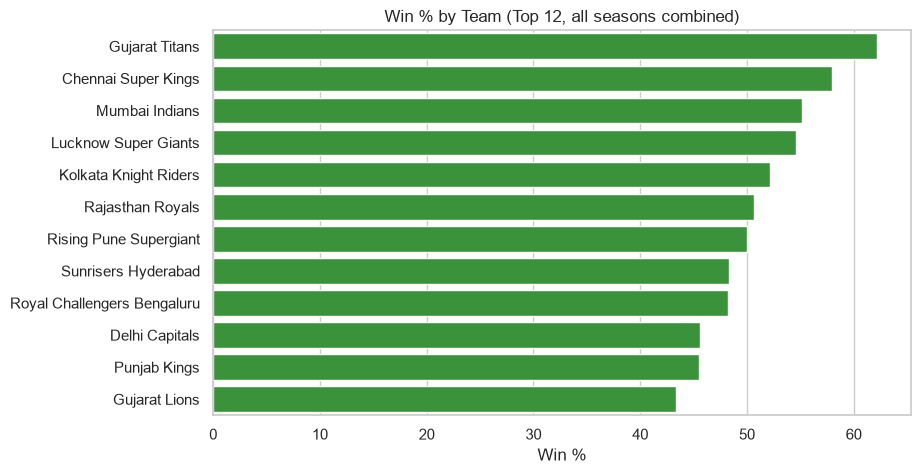

In [28]:
plt.figure(figsize=(9, 5))
sns.barplot(data=team_summary.head(12), y="team", x="win_pct", color="#2ca02c")
plt.title("Win % by Team (Top 12, all seasons combined)")
plt.xlabel("Win %"); plt.ylabel("")
plt.show()


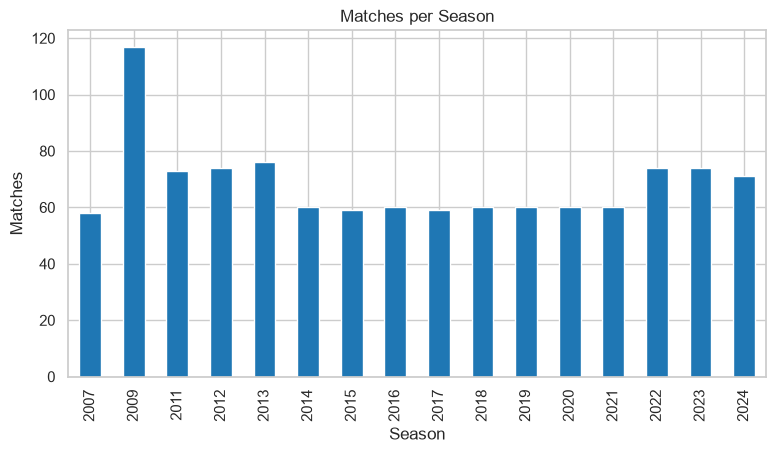

In [29]:
plt.figure(figsize=(9, 4.5))
match_level["season"].value_counts().sort_index().plot(kind="bar", color="#1f77b4")
plt.title("Matches per Season"); plt.xlabel("Season"); plt.ylabel("Matches")
plt.show()


### Match strategy — toss, batting order

Toss winner also won the match in 50.6% of games.


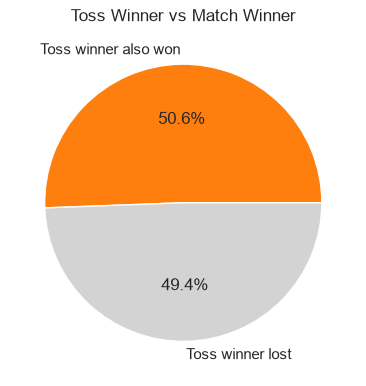

In [30]:
toss_rate = match_level["toss_winner_won_match"].mean() * 100
print(f"Toss winner also won the match in {toss_rate:.1f}% of games.")

plt.figure(figsize=(4.5, 4.5))
match_level["toss_winner_won_match"].value_counts(normalize=True).mul(100).plot(
    kind="pie", autopct="%.1f%%", labels=["Toss winner also won", "Toss winner lost"], colors=["#ff7f0e", "#d3d3d3"]
)
plt.ylabel(""); plt.title("Toss Winner vs Match Winner")
plt.show()


Batting first win %: 45.7 | Chasing win %: 53.9


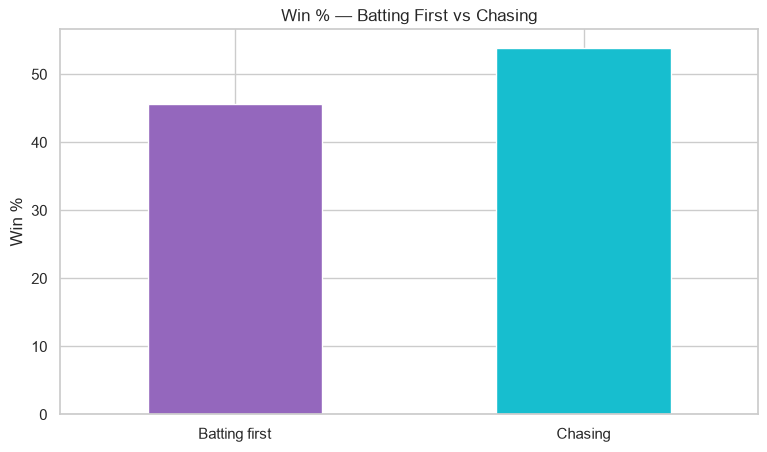

In [31]:
bat_first_pct = match_level["batting_first_won"].mean() * 100
chase_pct = match_level["chasing_won"].mean() * 100
print(f"Batting first win %: {bat_first_pct:.1f} | Chasing win %: {chase_pct:.1f}")

pd.Series({"Batting first": bat_first_pct, "Chasing": chase_pct}).plot(kind="bar", color=["#9467bd", "#17becf"], rot=0)
plt.title("Win % — Batting First vs Chasing"); plt.ylabel("Win %")
plt.show()


### Batting and bowling

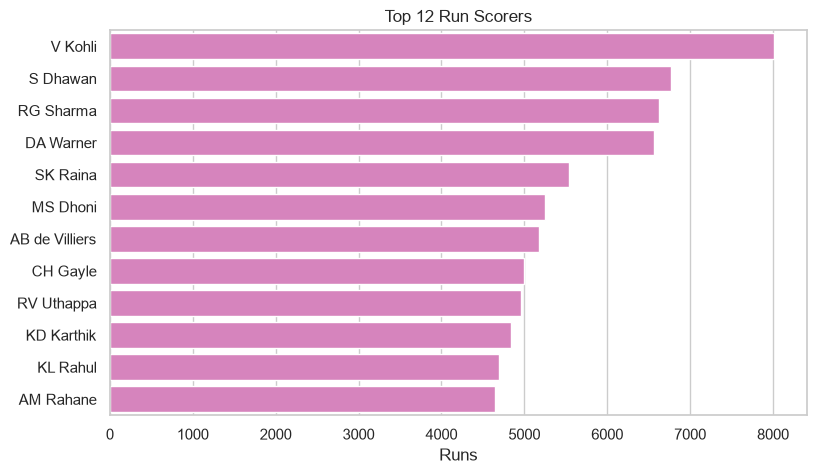

In [32]:
top_runs = batting_summary.head(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_runs["runs"], y=top_runs.index, color="#e377c2")
plt.title("Top 12 Run Scorers"); plt.xlabel("Runs"); plt.ylabel("")
plt.show()


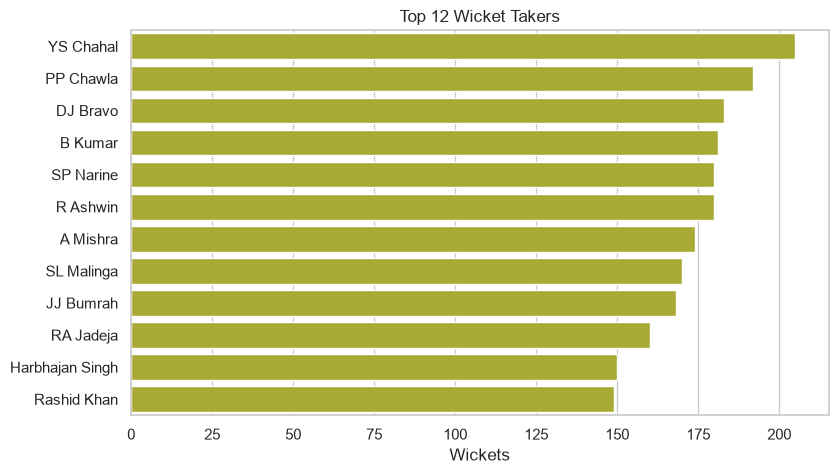

In [33]:
top_wkts = bowling_summary.head(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_wkts["wickets"], y=top_wkts.index, color="#bcbd22")
plt.title("Top 12 Wicket Takers"); plt.xlabel("Wickets"); plt.ylabel("")
plt.show()


### Phase analysis — Powerplay / Middle / Death

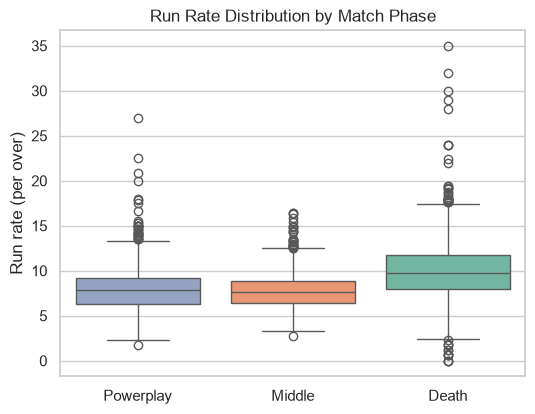

In [34]:
phase_g = deliveries.groupby(["match_id", "inning", "phase"]).agg(
    runs=("total_runs", "sum"), balls=("is_legal_ball", "sum")
).reset_index()
phase_g["run_rate"] = (phase_g["runs"] / (phase_g["balls"] / 6)).round(2)

plt.figure(figsize=(6, 4.5))
sns.boxplot(data=phase_g[phase_g["phase"].isin(["Powerplay", "Middle", "Death"])],
            x="phase", y="run_rate", order=["Powerplay", "Middle", "Death"],
            hue="phase", palette="Set2", legend=False)
plt.title("Run Rate Distribution by Match Phase"); plt.xlabel(""); plt.ylabel("Run rate (per over)")
plt.show()


## 6. Takeaways
• Toss impact: The toss winner also won the match in 50.6% of games. This is an association, not proof that winning the toss caused the win.

• Batting first vs chasing: Teams batting second won 53.9% of matches, compared with 45.7% when batting first.

• Leading run scorer: Virat Kohli with 8014 runs.

• Leading wicket taker: YS Chahal with 205 wickets.

• Phase pattern: Compare powerplay, middle-over and death-over scoring rates to understand how scoring patterns change throughout an innings.